In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [6]:
mnist = fetch_openml('mnist_784', version=1)

In [10]:
X=mnist.data
y=mnist.target.astype(int)

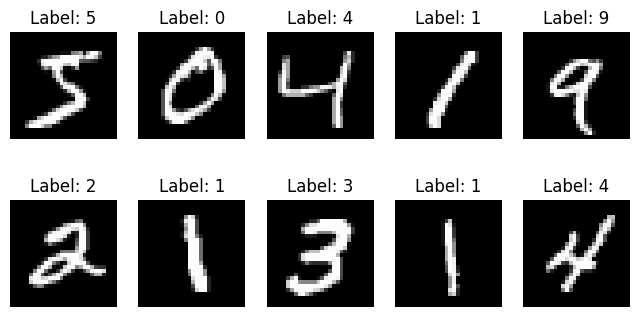

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X.iloc[i].values.reshape(28,28), cmap='gray')
    plt.title("Label: {}".format(y[i]))
    plt.axis('off')
plt.show()

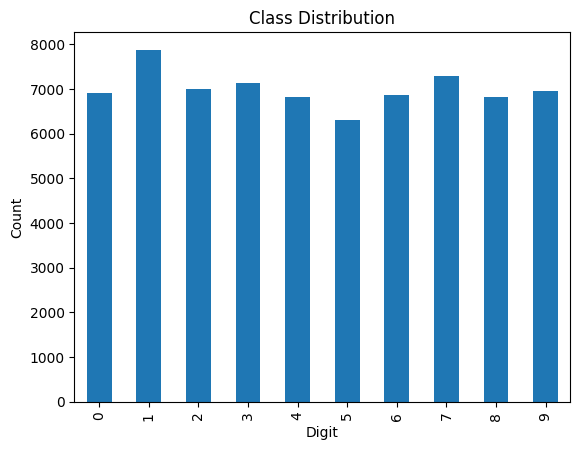

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

pd.Series(y).value_counts().sort_index().plot(kind='bar')
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)

In [14]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 64),
                    activation='relu',
                    solver='adam',
                    batch_size=64,
                    max_iter=20,
                    random_state=42)

mlp.fit(X_train, y_train)

C:\Users\navya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,64
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,20
,shuffle,True
,random_state,42


In [17]:
y_pred =mlp.predict(X_test)
print("accuracy",accuracy_score(y_test,y_pred))

accuracy 0.9692


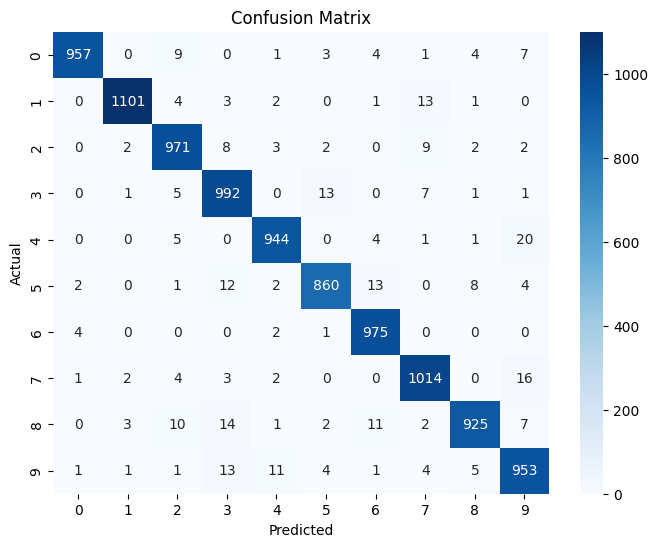

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
# im a cutie
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
